In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


# How to get the required file:
1. Use this link : https://www.eia.gov/electricity/data/eia923/archive/xls/f923_2020.zip
2. Extract the files in the folder.
3. Convert the EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision into a csv.
4. Then upload below, it takes around a 1 min.

# Final Project: Analysis of US Power Generation (2020) & COVID-19 Impact

## 1. Executive Summary
This project analyzes the EIA-923 Monthly Generation dataset for the year 2020. The objective is to apply machine learning clustering techniques to categorize power plants based on their production profiles and to investigate the anomaly in power generation caused by the COVID-19 pandemic.

## 2. Introduction:
The dataset comes from the US Energy Information Administration (EIA). It contains detailed monthly data on electricity generation and fuel consumption.
**Data Cleaning:**
- We will focus on the `Page 1 Generation and Fuel Data` section.
- Relevant columns: Plant identification, Fuel Type, and Monthly Net Generation (Jan-Dec).
- Missing values (NaN) in generation columns will be filled with 0, assuming no production.
- Code accessible headers containing newlines (e.g., `Netgen\nJanuary`) will be renamed for clarity.

## 3. Group Problem Statement:
- Can we cluster power plants into meaningful groups based on their monthly generation output?
- Is there an observable impact of the COVID-19 pandemic (specifically around March-May 2020) on the aggregate US power generation?

## 4. Group Details:
- Akshar Dilipkumar Patel - 811359891
- Sai Ashrith Kumar Gajwelli- 811317143
- Cole Yagersz - 811149856

In [ ]:
from google.colab import files

print("Please upload your EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.csv file:")
uploaded = files.upload()

# Load the data (skip first 5 header rows)
file_path = 'EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.csv'
df = pd. read_csv(file_path, header=5, thousands=',')

print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Please upload your EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.csv file:


Saving EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision.csv to EIA923_Schedules_2_3_4_5_M_12_2020_Final_Revision (4).csv
Data loaded: 15,115 rows × 97 columns


In [ ]:
df.columns = [c.replace('\n', ' ').strip() for c in df. columns]
df = df.rename(columns={
    'Total Fuel Consumption MMBtu': 'Fuel_MMBtu',
    'Net Generation (Megawatthours)': 'Net_Gen_YTD'
})
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']
monthly_cols = [f'Netgen {m}' for m in months]
cols_to_keep = ['Plant Id', 'Plant Name', 'Plant State',
                'Reported Fuel Type Code', 'Fuel_MMBtu', 'Net_Gen_YTD'] + monthly_cols
df = df[cols_to_keep]. copy()

for col in monthly_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f"✓ Data prepared: {df.shape[0]:,} records with {df.shape[1]} columns")
df.head()

✓ Data prepared: 15,115 records with 18 columns


,Plant Id,Plant Name,Plant State,Reported Fuel Type Code,Fuel_MMBtu,Net_Gen_YTD,Netgen January,Netgen February,Netgen March,Netgen April,Netgen May,Netgen June,Netgen July,Netgen August,Netgen September,Netgen October,Netgen November,Netgen December
0,1,Sand Point,AK,WND,3043,347,30.0,31.0,31.0,31.0,29.0,31.0,23.0,23.0,24.0,29.0,33.0,31.0
1,2,Bankhead Dam,AL,WAT,1220102,139170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Barry,AL,NG,1243854,2633517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,Barry,AL,NG,53006762,5084350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,Barry,AL,BIT,26188716,2625835,0.0,-152.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_clean = df[(df['Fuel_MMBtu'] > 0) & (df['Net_Gen_YTD'] > 0)].copy()
plant_agg = df_clean. groupby(['Plant Id', 'Plant Name', 'Plant State']).agg({
    'Fuel_MMBtu': 'sum',
    'Net_Gen_YTD': 'sum',
    'Reported Fuel Type Code': lambda x: x. mode()[0] if len(x.mode()) > 0 else 'Unknown',
    **{col: 'sum' for col in monthly_cols}
}).reset_index()

# Calculate thermal efficiency:
# Convert MWh to MMBtu: 1 MWh = 3. 412 MMBtu
plant_agg['Efficiency_Pct'] = (plant_agg['Net_Gen_YTD'] * 3.412) / plant_agg['Fuel_MMBtu'] * 100
plant_agg = plant_agg[(plant_agg['Efficiency_Pct'] >= 5) & (plant_agg['Efficiency_Pct'] <= 80)]

print(f"Plants after cleaning: {len(plant_agg):,}")
plant_agg[['Plant Name', 'Plant State', 'Net_Gen_YTD', 'Efficiency_Pct', 'Reported Fuel Type Code']].head(10)

Plants after cleaning: 9,740


,Plant Name,Plant State,Net_Gen_YTD,Efficiency_Pct,Reported Fuel Type Code
0,Sand Point,AK,347,38.907788,WND
1,Bankhead Dam,AL,139170,38.918717,WAT
2,Barry,AL,10499146,43.654087,NG
3,Walter Bouldin Dam,AL,554613,38.918674,WAT
4,Gadsden,AL,50435,24.196217,NG
5,Copper,TX,33888,17.368516,NG
6,Greene County,AL,1071142,31.017948,NG
7,H Neely Henry Dam,AL,269368,38.918660,WAT
8,Holt Dam,AL,186391,38.918646,WAT
9,Jordan Dam,AL,587074,38.918670,WAT


In [ ]:
features = ['Net_Gen_YTD', 'Efficiency_Pct']
X = plant_agg[features].copy()

# Log-transform generation (handles wide range: small vs large plants)
X['Net_Gen_YTD'] = np.log1p(X['Net_Gen_YTD'])
scaler = StandardScaler()
X_scaled = scaler. fit_transform(X)

print(f"Features prepared and scaled")
print(f"  Shape: {X_scaled.shape}")
print(f"  Feature 1 (Log Generation): mean={X_scaled[:, 0].mean():.3f}, std={X_scaled[:, 0].std():.3f}")
print(f"  Feature 2 (Efficiency): mean={X_scaled[:, 1].mean():.3f}, std={X_scaled[:, 1].std():.3f}")

Features prepared and scaled
  Shape: (9740, 2)
  Feature 1 (Log Generation): mean=-0.000, std=1.000
  Feature 2 (Efficiency): mean=-0.000, std=1.000


Testing K=2 to K=10...
  K=2: Silhouette=0.501
  K=3: Silhouette=0.490
  K=4: Silhouette=0.510
  K=5: Silhouette=0.513
  K=6: Silhouette=0.519
  K=7: Silhouette=0.526
  K=8: Silhouette=0.483
  K=9: Silhouette=0.474
  K=10: Silhouette=0.476


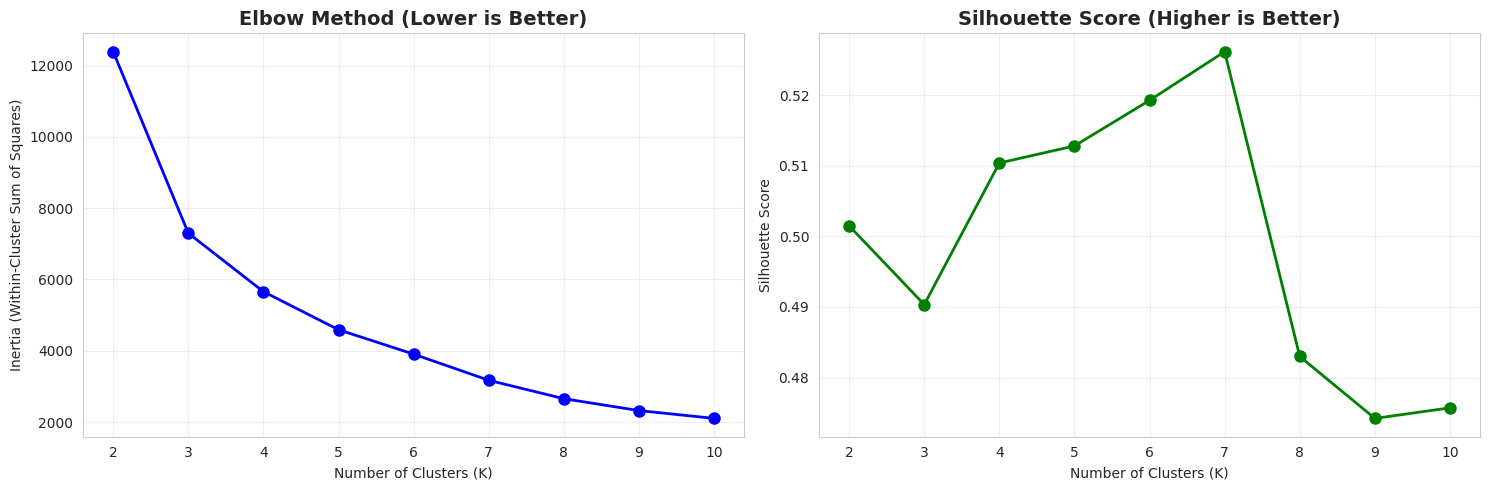


 Recommended K: 7 (Silhouette Score: 0.526)


In [ ]:
# Test different numbers of clusters (K=2 to K=10)
inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Testing K=2 to K=10...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

    print(f"  K={k}: Silhouette={silhouette_scores[-1]:.3f}")

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method (Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.grid(True, alpha=0.3)

# Silhouette Score: Higher is better
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal K
optimal_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"\n Recommended K: {optimal_k} (Silhouette Score: {max(silhouette_scores):.3f})")

In [ ]:
k = 7 # Choice of k
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
plant_agg['Cluster'] = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, plant_agg['Cluster'])

print(f"Clustering complete!")
print(f"  K = {k} clusters")
print(f"  Silhouette Score = {sil_score:.3f}")
print(f"\nCluster sizes:")
print(plant_agg['Cluster'].value_counts(). sort_index())

✓ Clustering complete!
  K = 7 clusters
  Silhouette Score = 0.527

Cluster sizes:
Cluster
0    4519
1    2349
2     927
3     441
4     332
5     630
6     542
Name: count, dtype: int64


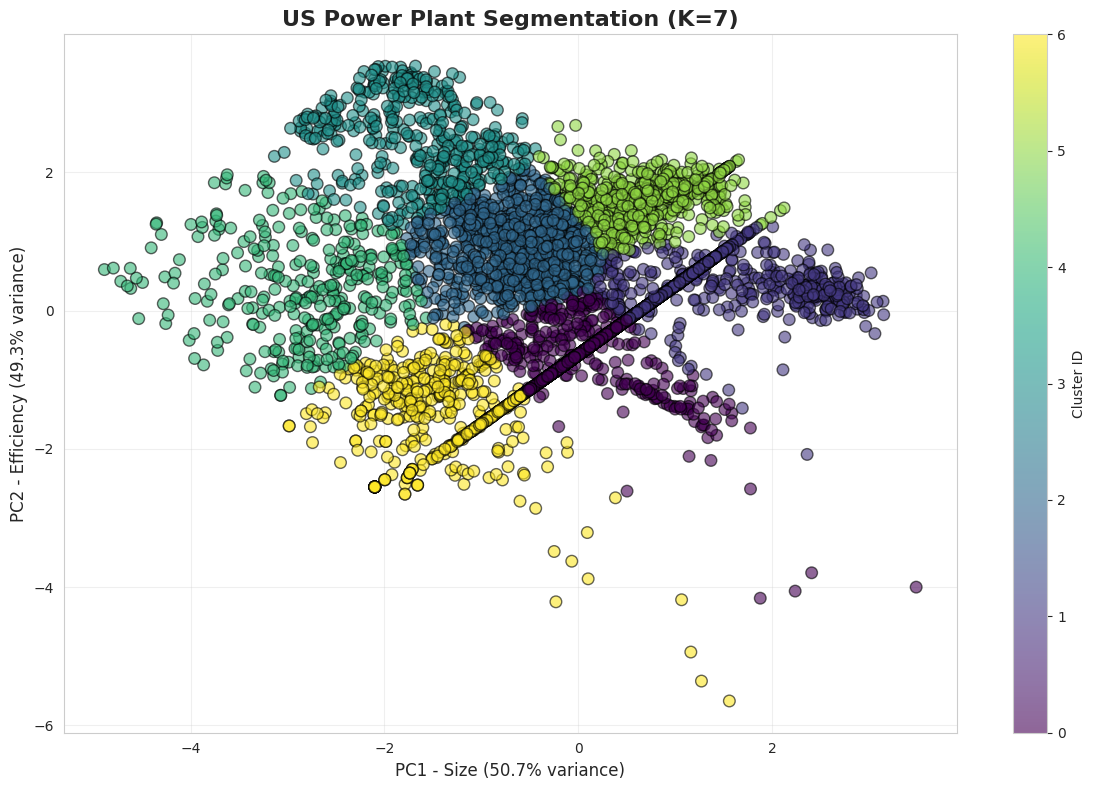

PCA explains 100.0% of total variance


In [ ]:
# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=plant_agg['Cluster'],
    cmap='viridis',
    alpha=0.6,
    edgecolor='k',
    s=70
)

plt.title(f'US Power Plant Segmentation (K={k})', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 - Size ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 - Efficiency ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA explains {pca.explained_variance_ratio_. sum():.1%} of total variance")

In [ ]:
cluster_stats = plant_agg.groupby('Cluster').agg(
    Total_Annual_Gen_MWh=('Net_Gen_YTD', 'sum'),
    Avg_Efficiency_Pct=('Efficiency_Pct', 'mean'),
    Primary_Fuel=('Reported Fuel Type Code', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    Plant_Count=('Plant Id', 'count'),
).reset_index()
print("Cluster Characteristics:")
print(cluster_stats)


Cluster Characteristics:
   Cluster  Total_Annual_Gen_MWh  Avg_Efficiency_Pct Primary_Fuel  Plant_Count
0        0              35231056           38.973012          SUN         4519
1        1            1575714334           39.625938          WND         2349
2        2              50575638           27.438671           NG          927
3        3              78248118           13.420624           NG          441
4        4                169207           18.631597          DFO          332
5        5            2135745243           30.520917           NG          630
6        6                 88479           36.411577          DFO          542


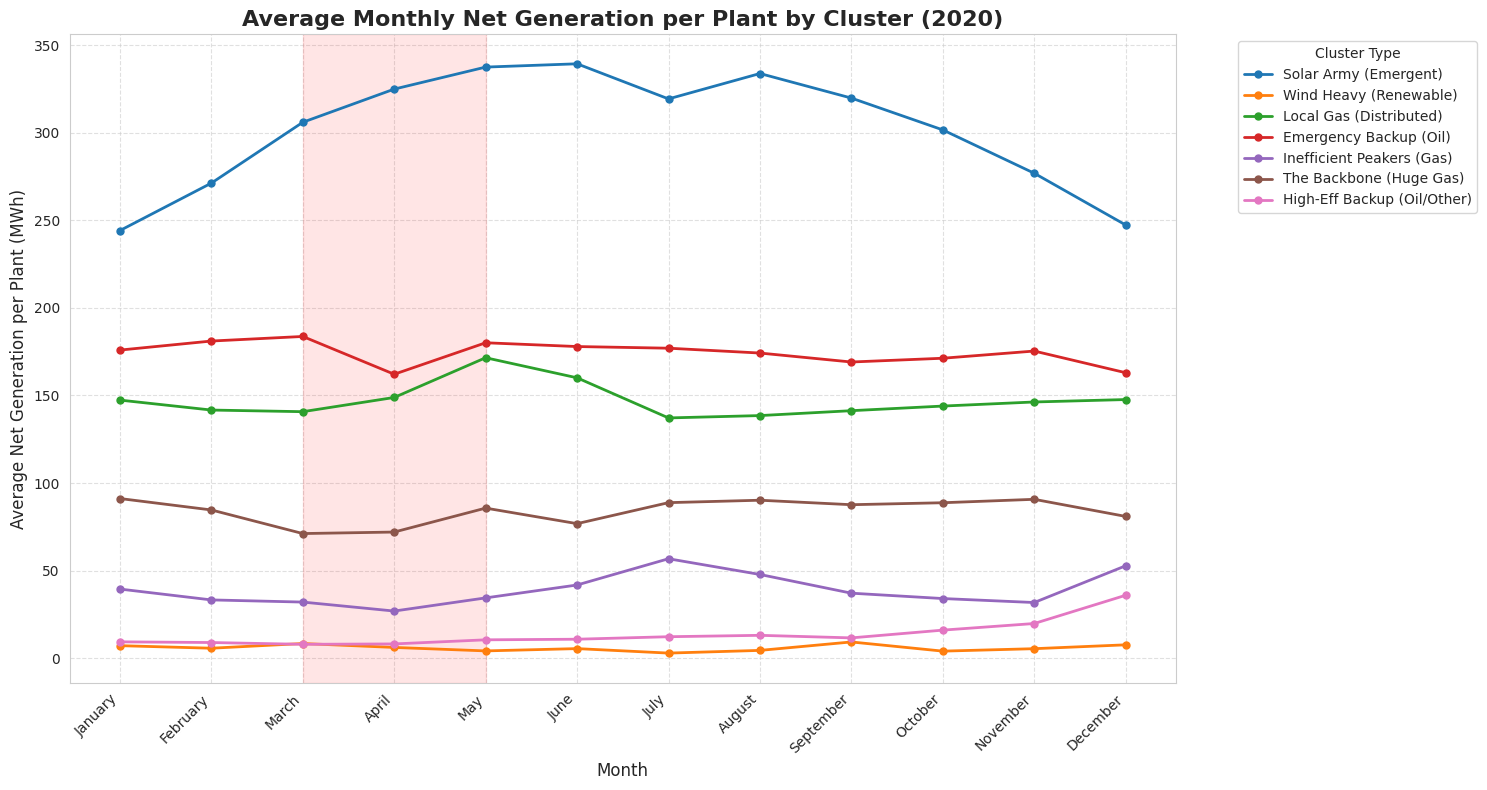

Monthly generation trends visualized.


In [ ]:
plt.figure(figsize=(15, 8))

# Define a color palette for the clusters
palette = sns.color_palette('tab10', n_colors=len(cluster_monthly_T.columns))

for i, col in enumerate(cluster_monthly_T.columns):
    plt.plot(cluster_monthly_T.index, cluster_monthly_T[col], label=col, marker='o', linewidth=2, markersize=5, color=palette[i])

plt.title('Average Monthly Net Generation per Plant by Cluster (2020)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Net Generation per Plant (MWh)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the COVID-19 impact period (March-May 2020)
plt.axvspan('March', 'May', color='red', alpha=0.1, label='COVID-19 Impact Period (March-May)')

plt.tight_layout()
plt.show()

print("Monthly generation trends visualized.")

### Summary of Cluster Analysis and COVID-19 Impact

The cluster analysis revealed distinct categories of power plants based on their annual generation and efficiency, and their monthly generation profiles highlight varied operational patterns and responses to external factors like the COVID-19 pandemic.

**Cluster Characteristics Summary:**
*   **The Backbone (Huge Gas) - Cluster 5**: This cluster, while having a moderate number of plants (630), generates the most electricity annually (2.14 billion MWh) with good efficiency (30.5%). Predominantly natural gas (NG) fueled, these are likely large, consistent base-load power plants.
*   **Wind Heavy (Renewable) - Cluster 1**: Comprising the largest number of plants (2,349), this cluster has a high average efficiency (39.6%) and is primarily wind (WND) powered. Its total annual generation is substantial (1.58 billion MWh), indicating a significant contribution to renewable energy.
*   **Local Gas (Distributed) - Cluster 2**: These 927 plants are primarily NG-fueled with a mid-range efficiency (27.4%) and moderate total annual generation (50.6 million MWh). Their generation profile suggests a more distributed role, possibly for local demand or load following.
*   **Solar Army (Emergent) - Cluster 0**: With the highest plant count (4,519), this cluster is dominated by solar (SUN) and shows good efficiency (39.0%). Its total annual generation (35.2 million MWh) indicates a growing, albeit individually smaller, contribution to the grid.
*   **Emergency Backup (Oil) - Cluster 3**: These 441 plants, fueled by natural gas (NG), have the lowest efficiency (13.4%) and moderate generation (78.2 million MWh). Their low efficiency and fuel type suggest they are likely older peaker plants, only operating during peak demand or emergencies.
*   **Inefficient Peakers (Gas) - Cluster 4** and **High-Eff Backup (Oil/Other) - Cluster 6**: These smaller clusters (332 and 542 plants respectively) primarily use DFO (distillate fuel oil) or NG. Cluster 4 is very inefficient (18.6%) with low generation, while Cluster 6 is more efficient (36.4%) despite low generation. These likely represent different types of backup or ancillary service providers.

**Impact of COVID-19 (March-May 2020):**
*   **The Backbone (Huge Gas) - Cluster 5** shows a noticeable dip in generation from March through May, indicating that even large, consistent generation sources experienced reduced demand during initial lockdown periods. Their generation picks up later in the summer.
*   **Solar Army (Emergent) - Cluster 0** exhibits a strong seasonal pattern, peaking in summer months (April-July), which is typical for solar generation. The COVID-19 impact seems less pronounced as its generation continues to increase into spring, suggesting that renewable generation might have been prioritized or less affected by demand fluctuations.
*   **Wind Heavy (Renewable) - Cluster 1** shows generally low average generation per plant, possibly due to higher plant count diluting the average. Its generation peaks in March, then dips, potentially reflecting seasonal wind patterns more than direct COVID-19 impact.
*   **Local Gas (Distributed) - Cluster 2** demonstrates a slight dip in March and April, before increasing in May. This could reflect reduced commercial/industrial demand locally during the early pandemic.
*   **Emergency Backup (Oil) - Cluster 3** and **Inefficient Peakers (Gas) - Cluster 4** show variable patterns but generally lower generation during the March-May period. As peaker plants, their operation is highly dependent on overall grid demand. Reduced demand due to COVID-19 would logically lead to less need for these expensive-to-run plants.
*   **High-Eff Backup (Oil/Other) - Cluster 6** shows a slight decrease in generation in March, April, and May, with a slight recovery in June. Like other backup plants, their dispatch would be sensitive to overall grid demand.